In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix,hstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    classification_report,confusion_matrix,ConfusionMatrixDisplay)
import joblib
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/asus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
data=pd.read_csv("phishing_email.csv")
print("Dataset Shape:", data.shape)
print()
print(data.info())
print("\nMissing Values")
print(data.isnull().sum())
print("\nDuplicate Rows")
print(data.duplicated().sum())
print("\nClass Distribution")
print(data["label"].value_counts())

Dataset Shape: (82486, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB
None

Missing Values
text_combined    0
label            0
dtype: int64

Duplicate Rows
408

Class Distribution
label
1    42891
0    39595
Name: count, dtype: int64


In [3]:
data = data.drop_duplicates().reset_index(drop=True)

print(f"Dataset Shape after removing duplicates: {data.shape}")

X = data["text_combined"]
y = data["label"]

Dataset Shape after removing duplicates: (82078, 2)


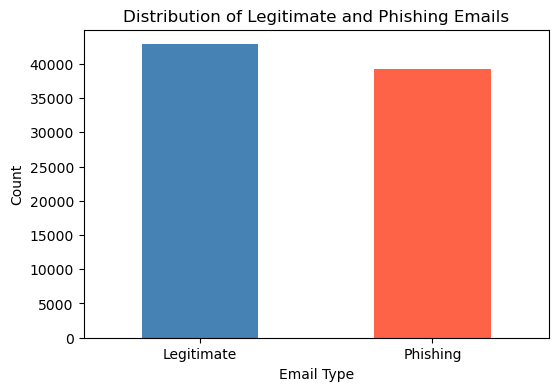

In [4]:
plt.figure(figsize=(6,4))
data["label"].value_counts().plot(
    kind="bar",
    color=["steelblue","tomato"]
)
plt.xticks([0,1],["Legitimate","Phishing"],rotation=0)

plt.title("Distribution of Legitimate and Phishing Emails")

plt.xlabel("Email Type")

plt.ylabel("Count")

plt.show()

In [5]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)


In [6]:
data["clean_text"] = data["text_combined"].apply(clean_text)
X = data["clean_text"]

In [9]:
def url_count(text):
    return len(re.findall(r'http[s]?://|www\.', text))
def email_count(text):
    return len(re.findall(r'\S+@\S+', text))
def digit_count(text):
    return sum(c.isdigit() for c in text)
def capital_count(text):
    return sum(c.isupper() for c in text)
def exclamation_count(text):
    return text.count("!")
def email_length(text):
    return len(text)
def word_count(text):
    return len(text.split())

SUSPICIOUS_KEYWORDS = ["verify","account","password","login","click","urgent","bank","security","confirm","update"]
def suspicious_keyword_count(text):
    SUSPICIOUS_KEYWORDS
    text = text.lower()
    count = 0
    for word in SUSPICIOUS_KEYWORDS:
        count += len(re.findall(rf"\b{word}\b", text))
    return count

In [10]:
data["url_count"]=data["text_combined"].apply(url_count)
data["email_count"]=data["text_combined"].apply(email_count)
data["digit_count"]=data["text_combined"].apply(digit_count)
data["capital_count"]=data["text_combined"].apply(capital_count)
data["exclamation_count"]=data["text_combined"].apply(exclamation_count)
data["email_length"]=data["text_combined"].apply(email_length)
data["word_count"]=data["text_combined"].apply(word_count)
data["keyword_count"] = data["text_combined"].apply(suspicious_keyword_count)

In [11]:
vectorizer = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1, 2),
    stop_words='english'
)
X_tfidf = vectorizer.fit_transform(X)
print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))

Vocabulary Size: 7000


In [12]:
extra_features = csr_matrix(
    data[
        [
            "url_count",
            "email_count",
            "digit_count",
            "capital_count",
            "exclamation_count",
            "email_length",
            "word_count",
            "keyword_count"
        ]
    ].values
)

X_vec = hstack([X_tfidf, extra_features])

In [13]:
X_train, X_test, y_train, y_test=train_test_split(X_vec,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(solver="saga",max_iter=3000,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1),
    "Naive Bayes": MultinomialNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

Model: Logistic Regression
Accuracy : 0.4778
Precision: 0.4474
Recall   : 0.0020
F1 Score : 0.0040

Classification Report
              precision    recall  f1-score   support

           0       0.48      1.00      0.65      7847
           1       0.45      0.00      0.00      8569

    accuracy                           0.48     16416
   macro avg       0.46      0.50      0.33     16416
weighted avg       0.46      0.48      0.31     16416



/home/asus/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


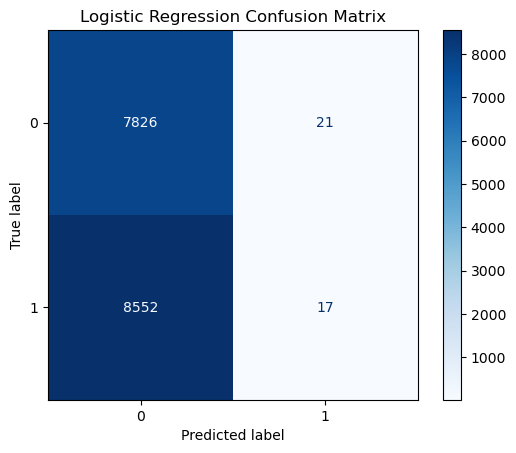

Model: Random Forest
Accuracy : 0.9893
Precision: 0.9888
Recall   : 0.9907
F1 Score : 0.9897

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7847
           1       0.99      0.99      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



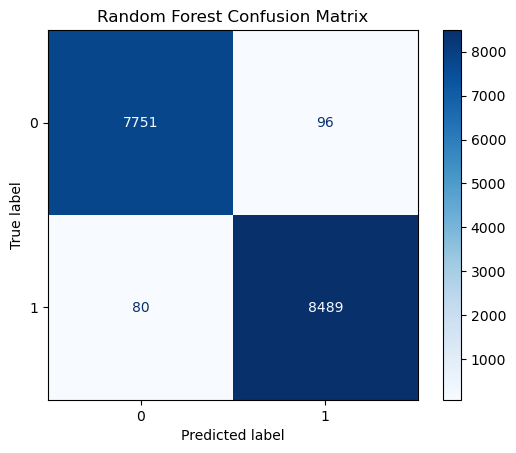

Model: Naive Bayes
Accuracy : 0.8043
Precision: 0.8914
Recall   : 0.7118
F1 Score : 0.7915

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      7847
           1       0.89      0.71      0.79      8569

    accuracy                           0.80     16416
   macro avg       0.82      0.81      0.80     16416
weighted avg       0.82      0.80      0.80     16416



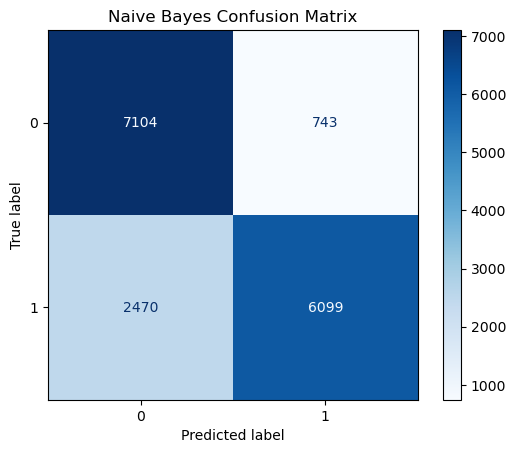

Model: Neural Network
Accuracy : 0.9805
Precision: 0.9732
Recall   : 0.9900
F1 Score : 0.9815

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7847
           1       0.97      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



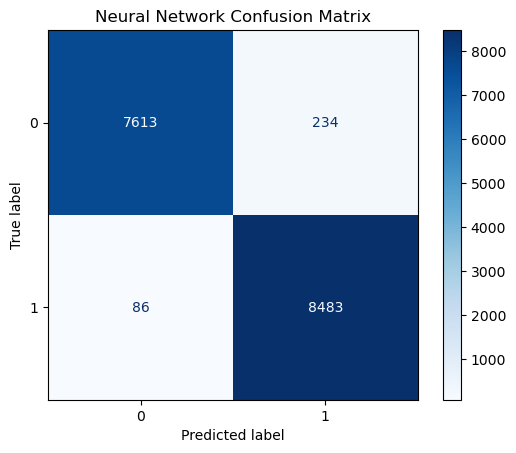

In [15]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    cm = confusion_matrix(y_test, preds)

    print("=" * 60)
    print(f"Model: {name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}\n")

    print("Classification Report")
    print(classification_report(y_test, preds, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test,preds,cmap="Blues")

    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [16]:
rf_model = models["Random Forest"]

In [17]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9893,0.9888,0.9907,0.9897
1,Neural Network,0.9805,0.9732,0.9900,0.9815
2,Naive Bayes,0.8043,0.8914,0.7118,0.7915
3,Logistic Regression,0.4778,0.4474,0.0020,0.0040


In [18]:
engineered_features = [
    "url_count",
    "email_count",
    "digit_count",
    "capital_count",
    "exclamation_count",
    "email_length",
    "word_count",
    "keyword_count"
]
feature_names = (list(vectorizer.get_feature_names_out()) + engineered_features)
importances = rf_model.feature_importances_

assert len(feature_names) == len(importances), "Feature names and importances do not match!"

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print(feature_importance.head(20))

           Feature  Importance
6932         wrote    0.023316
864       aug 2008    0.019866
7002   digit_count    0.018204
862            aug    0.016588
2263         enron    0.015470
250           2008    0.014332
7005  email_length    0.013735
7006    word_count    0.011036
4844            pm    0.008631
4198         money    0.007944
6256         thank    0.007816
3932     mail list    0.007678
3789          list    0.007293
1412         click    0.007232
6809        wed 06    0.006682
1267            cc    0.006644
5092      question    0.006448
6050       subject    0.006132
3064          http    0.006036
55              06    0.005992


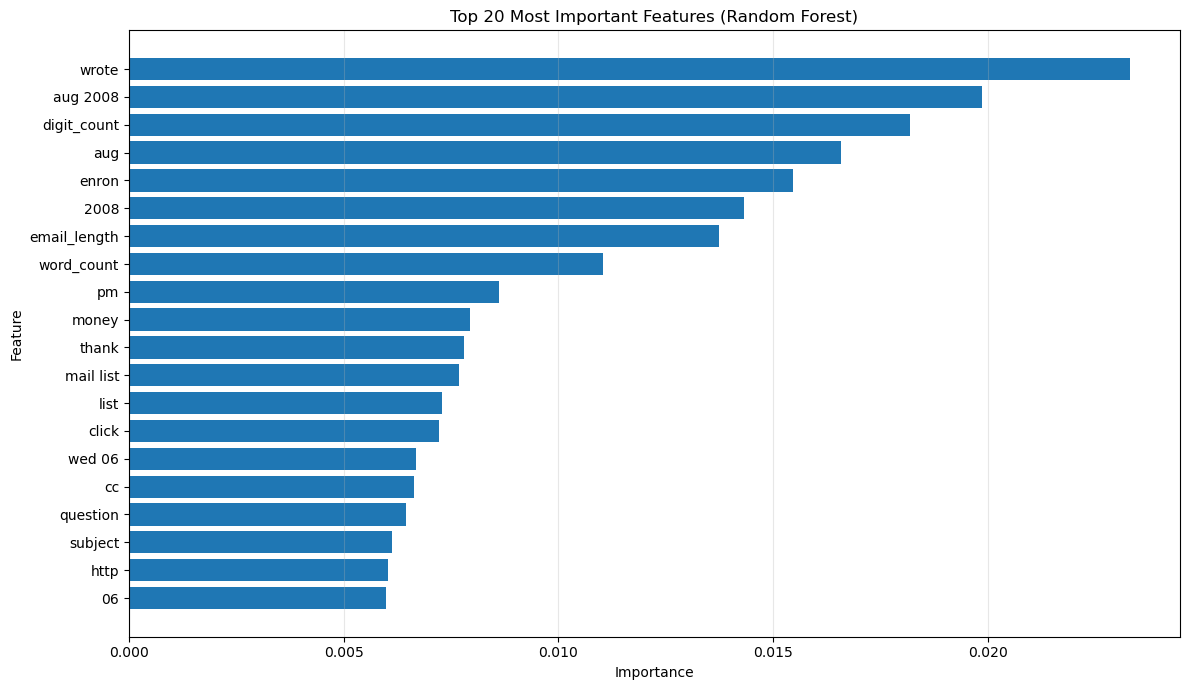

In [19]:
top_features = feature_importance.head(20)
plt.figure(figsize=(12,7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.grid(axis="x", alpha=0.3)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(models["Random Forest"], "phishing_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Random Forest model and TF-IDF vectorizer saved successfully.")

Random Forest model and TF-IDF vectorizer saved successfully.


In [21]:
user_email = input("Enter an email:\n")

cleaned = clean_text(user_email)

tfidf_features = vectorizer.transform([cleaned])

extra_features = pd.DataFrame([{
    "url_count": url_count(user_email),
    "email_count": email_count(user_email),
    "digit_count": digit_count(user_email),
    "capital_count": capital_count(user_email),
    "exclamation_count": exclamation_count(user_email),
    "email_length": email_length(user_email),
    "word_count": word_count(user_email),
    "keyword_count": suspicious_keyword_count(user_email)
}])

extra_sparse = csr_matrix(extra_features.values)

final_features = hstack([tfidf_features, extra_sparse])

prediction = rf_model.predict(final_features)

if prediction[0] == 1:
    print("\n⚠️ Prediction: Phishing Email")
else:
    print("\n✅ Prediction: Legitimate Email")

Enter an email:
 Subject: URGENT: Verify Your Bank Account Immediately  Dear Customer,  Your online banking account has been temporarily suspended due to unusual activity.  To restore access, you must verify your account within 24 HOURS.  Click here immediately: https://secure-bank-verification-login.com/account/verify  Failure to verify will permanently disable your account.  Account ID: 84729165  Thank you, Bank Security Team support@secure-bank-verification-login.com



⚠️ Prediction: Phishing Email


In [23]:
user_email = input("Enter an email:\n")

cleaned = clean_text(user_email)

tfidf_features = vectorizer.transform([cleaned])

extra_features = pd.DataFrame([{
    "url_count": url_count(user_email),
    "email_count": email_count(user_email),
    "digit_count": digit_count(user_email),
    "capital_count": capital_count(user_email),
    "exclamation_count": exclamation_count(user_email),
    "email_length": email_length(user_email),
    "word_count": word_count(user_email),
    "keyword_count": suspicious_keyword_count(user_email)
}])

extra_sparse = csr_matrix(extra_features.values)

final_features = hstack([tfidf_features, extra_sparse])

prediction = rf_model.predict(final_features)

if prediction[0] == 1:
    print("\n⚠️ Prediction: Phishing Email")
else:
    print("\n✅ Prediction: Legitimate Email")

Enter an email:
 Subject: GitHub Security Update  Hello,  GitHub has introduced new security recommendations.  Read more at:  https://github.com/security  Thank you.



✅ Prediction: Legitimate Email


In [24]:
user_email = input("Enter an email:\n")

cleaned = clean_text(user_email)

tfidf_features = vectorizer.transform([cleaned])

extra_features = pd.DataFrame([{
    "url_count": url_count(user_email),
    "email_count": email_count(user_email),
    "digit_count": digit_count(user_email),
    "capital_count": capital_count(user_email),
    "exclamation_count": exclamation_count(user_email),
    "email_length": email_length(user_email),
    "word_count": word_count(user_email),
    "keyword_count": suspicious_keyword_count(user_email)
}])

extra_sparse = csr_matrix(extra_features.values)

final_features = hstack([tfidf_features, extra_sparse])

prediction = rf_model.predict(final_features)

if prediction[0] == 1:
    print("\n⚠️ Prediction: Phishing Email")
else:
    print("\n✅ Prediction: Legitimate Email")

Enter an email:
 Subject: Congratulations!!!  YOU HAVE WON £5,000!!!  Claim your reward NOW.  Visit  http://winner-claim-prize.xyz  and enter your verification code:  983472  Hurry!! Offer expires today!!  Congratulations!



⚠️ Prediction: Phishing Email


In [26]:
user_email = input("Enter an email:\n")

cleaned = clean_text(user_email)

tfidf_features = vectorizer.transform([cleaned])

extra_features = pd.DataFrame([{
    "url_count": url_count(user_email),
    "email_count": email_count(user_email),
    "digit_count": digit_count(user_email),
    "capital_count": capital_count(user_email),
    "exclamation_count": exclamation_count(user_email),
    "email_length": email_length(user_email),
    "word_count": word_count(user_email),
    "keyword_count": suspicious_keyword_count(user_email)
}])

extra_sparse = csr_matrix(extra_features.values)

final_features = hstack([tfidf_features, extra_sparse])

prediction = rf_model.predict(final_features)

if prediction[0] == 1:
    print("\n⚠️ Prediction: Phishing Email")
else:
    print("\n✅ Prediction: Legitimate Email")

Enter an email:
 Subject: Mid-Semester Examination Schedule  Dear Students,  The mid-semester examination timetable has been published on the university portal.  Please review your exam dates and report any discrepancies to the academic office before Monday.  Regards, Department of Computer Science



✅ Prediction: Legitimate Email
